Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.79MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.75MB/s]


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



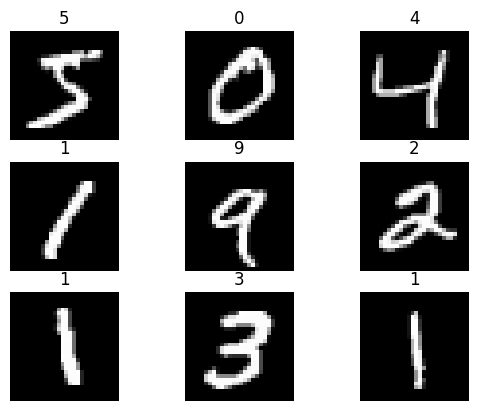

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Using cpu device
CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
  )
  (out): Linear(in_features=3136, out_features=10, bias=True)
)
Test result: 
 Accuracy: 98.17%, Avg loss: 0.053271682734482934


In [1]:
'''
 MNIST包含70,000张手写数字图像: 60,000张用于训练，10,000张用于测试。
 图像是灰度的，28x28像素的，并且居中的，以减少预处理和加快运行。
'''
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

'''下载训练数据集（包含训练图片+标签）'''
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),#张量
)   #对于pytorch库能够识别的数据一般是tensor张力
# datasets.MNIST的参数：
#   root(string)： 表示数据集的根目录，
#   train(bool, optional)： 如果为True，则从training.pt创建数据集，否则从test.pt创建数据集
#   download(bool, optional)： 如果为True，则从internet下载数据集并将其放入根目录。如果数据集已下载，则不会再次下载
#   transform(callable, optional)： 接收PIL图片并返回转换后版本图片的转换函数

'''下载测试数据集（包含训练图片+标签） '''
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)
# print(len(training_data))

'''展示手写字图片，把训练数据集中的前9张图片展示一下'''
from matplotlib import pyplot as plt
figure = plt.figure()
for i in range(9):
    img, label = training_data[i]#0
    figure.add_subplot(3, 3, i+1)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

'''创建数据DataLoader（数据加载器）
    batch_size:将数据集分成多份，每一份为batch_size个数据。
           优点：可以减少内存的使用，提高训练速度。
'''
train_dataloader = DataLoader(training_data, batch_size=64)#64张图片为一个包，
test_dataloader = DataLoader(test_data, batch_size=64)
for X, y in test_dataloader:#X是表示打包好的每一个数据包
    print(f"Shape of X [N, C, H, W]: {X.shape}")#
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

'''判断当前设备是否支持GPU，其中mps是苹果m系列芯片的GPU。'''
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

''' 定义神经网络  '''


class CNN(nn.Module):
    def __init__(self):         # 输入大小 (1, 28, 28)
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(  #将多个层组合成一起。
            nn.Conv2d(          #2d一般用于图像，3d用于视频数据（多一个时间维度），1d一般用于结构化的序列数据
                in_channels=1,  # 图像通道个数，1表示灰度图（确定了卷积核 组中的个数），彩色是3
                out_channels=16,# 要得到几多少个特征图，卷积核的个数
                kernel_size=5,  # 卷积核大小，5*5
                stride=1,       # 步长
                padding=2,      # 一般希望卷积核处理后的结果大小与处理前的数据大小相同，效果会比较好。那padding改如何设计呢？建议stride为1，kernel_size = 2*padding+1
            ),                  # 输出的特征图为 (16, 28, 28)
            nn.ReLU(),  # relu层
            nn.MaxPool2d(kernel_size=2),  # 进行池化操作（2x2 区域）, 输出结果为： (16, 14, 14)
        )
        self.conv2 = nn.Sequential(  #输入 (16, 14, 14)
            nn.Conv2d(16, 32, 5, 1, 2),  # 输出 (32, 14, 14)
            nn.ReLU(),  # relu层
            nn.Conv2d(32, 32, 5, 1, 2), # 输出 (32, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2),  # 输出 (32, 7, 7)
        )

        self.conv3 = nn.Sequential(  #输入 (32, 7, 7)
            nn.Conv2d(32, 64, 5, 1, 2),
            nn.ReLU(),  # 输出 (64, 7, 7)
        )

        self.out = nn.Linear(64 * 7 * 7, 10)  # 全连接层得到的结果

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)# 输出 (64,64, 7, 7)
        x = x.view(x.size(0), -1)  # flatten操作，结果为：(batch_size, 64 * 7 * 7)
        output = self.out(x)
        return output

model = CNN().to(device)
print(model)

def train(dataloader, model, loss_fn, optimizer):
    model.train()
#pytorch提供2种方式来切换训练和测试的模式，分别是：model.train() 和 model.eval()。
# 一般用法是：在训练开始之前写上model.trian()，在测试时写上 model.eval() 。
    batch_size_num = 1
    for X, y in dataloader:                 #其中batch为每一个数据的编号
        X, y = X.to(device), y.to(device)   #把训练数据集和标签传入cpu或GPU
        pred = model.forward(X)             #自动初始化 w权值
        loss = loss_fn(pred, y)             #通过交叉熵损失函数计算损失值loss
        # Backpropagation 进来一个batch的数据，计算一次梯度，更新一次网络
        optimizer.zero_grad()               #梯度值清零
        loss.backward()                     #反向传播计算得到每个参数的梯度值
        optimizer.step()                    #根据梯度更新网络参数

        loss = loss.item()                  #获取损失值
        # print(f"loss: {loss:>7f}  [number:{batch_size_num}]")
        batch_size_num += 1

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()    #
    test_loss, correct = 0, 0
    with torch.no_grad():   #一个上下文管理器，关闭梯度计算。当你确认不会调用Tensor.backward()的时候。这可以减少计算所用内存消耗。
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model.forward(X)
            test_loss += loss_fn(pred, y).item() #
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            a = (pred.argmax(1) == y)  #dim=1表示每一行中的最大值对应的索引号，dim=0表示每一列中的最大值对应的索引号
            b = (pred.argmax(1) == y).type(torch.float)
    test_loss /= num_batches
    correct /= size
    print(f"Test result: \n Accuracy: {(100*correct)}%, Avg loss: {test_loss}")

loss_fn = nn.CrossEntropyLoss() #创建交叉熵损失函数对象，因为手写字识别中一共有10个数字，输出会有10个结果
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#创建一个优化器，SGD为随机梯度下降算法？？
#params：要训练的参数，一般我们传入的都是model.parameters()。
#lr：learning_rate学习率，也就是步长。


train(train_dataloader, model, loss_fn, optimizer)
test(test_dataloader, model, loss_fn)


# epochs = 10 #
# for t in range(epochs):
#     print(f"Epoch {t+1}\n-------------------------------")
#     train(train_dataloader, model, loss_fn, optimizer)
#     # test(test_dataloader, model, loss_fn)
# print("Done!")
# test(test_dataloader, model, loss_fn)
#
#
#
# #分析sigmiod，relu
# # sgd，Adam